In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

Accuracy: 0.9586


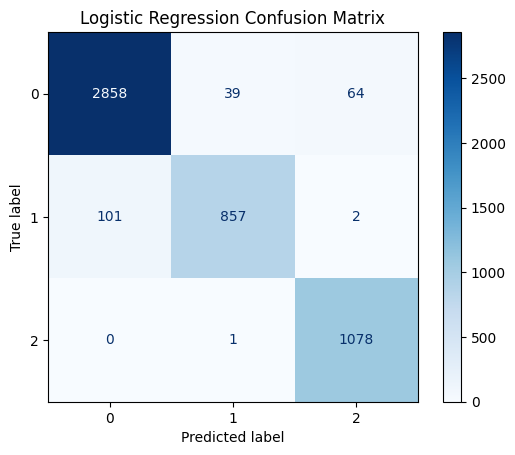

In [7]:
data = pd.read_csv("star_classification.csv")

data["redshift"] = 1/(1+data["redshift"])

X = data[["u","g","r","i","z","redshift"]].to_numpy()
y = data["class"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

model = LogisticRegression(solver="lbfgs", max_iter=5000)
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [15]:
y_pred

array(['QSO', 'GALAXY', 'STAR', ..., 'GALAXY', 'STAR', 'GALAXY'],
      dtype=object)

In [21]:
# galaxy accuracy
galaxy_mask = np.where(y_test=='GALAXY')
galaxies_correct = np.mean((y_test[galaxy_mask]==y_pred[galaxy_mask]))

# quasar accuracy
quasar_mask = np.where(y_test=='QSO')
quasar_correct = np.mean((y_test[quasar_mask]==y_pred[quasar_mask]))

# star accuracy
star_mask = np.where(y_test=='STAR')
star_correct = np.mean((y_test[star_mask]==y_pred[star_mask]))

print(f'Galaxy accuracy: {(galaxies_correct*100):.2f}%')
print(f'Quasar accuracy: {(quasar_correct*100):.2f}%')
print(f'Star accuracy: {(star_correct*100):.2f}%')

Galaxy accuracy: 96.52%
Quasar accuracy: 89.27%
Star accuracy: 99.91%


In [20]:
star_mask

(array([], dtype=int64),)